## Ch12. Advanced forecasting methods Forecasting: Principles & Practice (Python Edition) Extracted from: fpppy-12-advanced.qmd

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## [Slide 3] Case Study: Bank Call Volume

In [2]:
bank_calls = pd.read_csv("data/bank_calls.csv", parse_dates=["ds"])


In [3]:
import numpy as np
from statsforecast import StatsForecast
from statsforecast.models import MSTL

model = MSTL(season_length=[169, 169 * 5])
sf = StatsForecast(models=[model], freq="5min")
sf = sf.fit(
    bank_calls.assign(y=lambda df: np.sqrt(df["y"]))
)
dcmp = sf.fitted_[0, 0].model_

## [Slide 5] MSTL: Forecasting Strategy

In [4]:
import pandas as pd

Generate only business-hour timestamps (Mon-Fri, 7am-9pm)

In [5]:
start = bank_calls["ds"].max() + pd.offsets.Minute(5)
all_5min = pd.date_range(
    start, start + pd.offsets.Day(7), freq="5min"
)
fc_ds = all_5min.to_series().loc[lambda x: (
    x.dt.weekday.between(0, 4) &
    x.dt.strftime("%H:%M").between("07:00", "21:00")
)]

fc = sf.predict(h=len(fc_ds), level=[80, 95])

Back-transform from sqrt scale

In [6]:
res = fc.select_dtypes(include=np.number)
fc = fc.assign(**res.transform(lambda x: x**2))

## [Slide 8] Dynamic Harmonic Regression: Code

In [7]:
from utilsforecast.feature_engineering import fourier, pipeline
from statsforecast.models import AutoARIMA
from functools import partial

features = [
    partial(fourier, season_length=169, k=10),
    partial(fourier, season_length=5 * 169, k=5),
]
bank_fourier, bank_futr = pipeline(
    bank_calls, features=features,
    freq="5min", h=len(fc_ds)
)

Drop redundant Fourier features (sin5_845, cos5_845
are identical to sin5_169*5 = exact collinear)

In [8]:
dropcols = ["sin5_845", "cos5_845"]
bank_fourier = bank_fourier.drop(columns=dropcols)
bank_futr    = bank_futr.drop(columns=dropcols)

model = AutoARIMA(d=0, seasonal=False, nmodels=5)
sf = StatsForecast(models=[model], freq="5min")
sf = sf.fit(bank_fourier)
fc_fourier = sf.predict(
    h=len(fc_ds), X_df=bank_futr, level=[80, 95]
)

## [Slide 10] Electricity Demand: Multiple Seasonalities

In [9]:
vic_elec_df = pd.read_csv("data/vic_elec.csv", parse_dates=["ds"]).rename(columns={"y": "Demand"})


In [10]:
from statsforecast.models import AutoARIMA

# NOTE: the full vic_elec_df has ~105k half-hourly rows; an ARIMA fit with
# 36 Fourier exogenous columns (k=10+5+3) over the full series is not
# tractable on this shared machine (it ran for 40+ minutes using 40GB+ RAM
# before being stopped). Using the most recent 90 days keeps the same
# multiple-seasonality technique demonstrable at a practical cost.
vic_elec_recent = vic_elec_df.tail(90 * 48).reset_index(drop=True)

features = [
    partial(fourier, season_length=2 * 24,         k=10),
    partial(fourier, season_length=2 * 24 * 7,     k=5),
]
vic_fourier, vic_futr = pipeline(
    vic_elec_recent, features=features, freq="30min",
    h=2 * 48
)

model = AutoARIMA(max_d=0, seasonal=False, nmodels=20)
sf = StatsForecast(models=[model], freq="30min")
sf = sf.fit(vic_fourier, target_col="Demand")


## [Slide 14] Prophet: Cement Production Example

In [11]:
cement = (
    pd.read_csv("data/aus_production.csv", parse_dates=["ds"])
    [["ds", "Cement"]]
    .rename(columns={"Cement": "y"})
    .assign(unique_id="Cement")
)
train = cement[["ds", "y"]]


In [12]:
from prophet import Prophet

m = Prophet(weekly_seasonality=False)
m.add_seasonality(name="quarterly", period=4, fourier_order=2)
m.fit(train)

future = m.make_future_dataframe(periods=10, freq="QS")
fc_prophet = (
    m.predict(future)
    [["ds", "yhat", "yhat_lower", "yhat_upper"]]
    .rename(columns={
        "yhat":       "Prophet",
        "yhat_lower": "Prophet-lo-80",
        "yhat_upper": "Prophet-hi-80",
    })
)

Importing plotly failed. Interactive plots will not work.


08:49:51 - cmdstanpy - INFO - Chain [1] start processing


08:49:51 - cmdstanpy - INFO - Chain [1] done processing


## [Slide 18] AutoARIMAProphet and NeuralProphet

In [13]:
train = vic_elec_df.rename(columns={"y": "y"})[["ds", "y"]]


KeyError: "['y'] not in index"

In [14]:
from statsforecast.models import AutoARIMAProphet

m = AutoARIMAProphet()
m.add_seasonality(
    name="hourly",    period=48, fourier_order=5)
m.add_seasonality(
    name="subhourly", period=48*7, fourier_order=5)
m.fit(train)

future = m.make_future_dataframe(periods=48*2, freq="30T")
fc_ap = m.predict(future)

ImportError: cannot import name 'AutoARIMAProphet' from 'statsforecast.models' (/Data2/data/jc25/forecast/fpppy-labs/.venv/lib/python3.11/site-packages/statsforecast/models.py)

## [Slide 23] VAR: US Consumption and Income

In [15]:
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

us_change = (
    pd.read_csv("data/US_change.csv", parse_dates=["ds"])
    .rename(columns={"y": "Consumption"})
    .drop(columns=["unique_id"])
    .set_index("ds").asfreq("QS")
)

model = VAR(us_change)
fit_aic = model.fit(ic="aic")
fit_bic = model.fit(ic="bic")
print("Lags selected by AIC:", fit_aic.k_ar)  # VAR(5)
print("Lags selected by BIC:", fit_bic.k_ar)  # VAR(1)

Lags selected by AIC: 5
Lags selected by BIC: 1


## [Slide 25] VAR: Forecasting

In [16]:
lag_order = fit_aic.k_ar
y = us_change.tail(lag_order).to_numpy()

fc80 = fit_aic.forecast_interval(y, steps=8, alpha=0.2)
fc95 = fit_aic.forecast_interval(y, steps=8, alpha=0.05)

fc_var5 = pd.concat([
    pd.DataFrame({
        "unique_id": column,
        "ds": pd.date_range("2019-07-01", periods=8, freq="QS"),
        "VAR_5":      fc80[0][:, i],
        "VAR_5-lo-80": fc80[1][:, i],
        "VAR_5-hi-80": fc80[2][:, i],
    })
    for i, column in enumerate(["Consumption", "Income"])
])

## [Slide 27] VAR: Additional Applications Granger causality test

In [17]:
from statsmodels.tsa.stattools import grangercausalitytests
results = grangercausalitytests(
    us_change[["Consumption", "Income"]],
    maxlag=5
)

Impulse response function

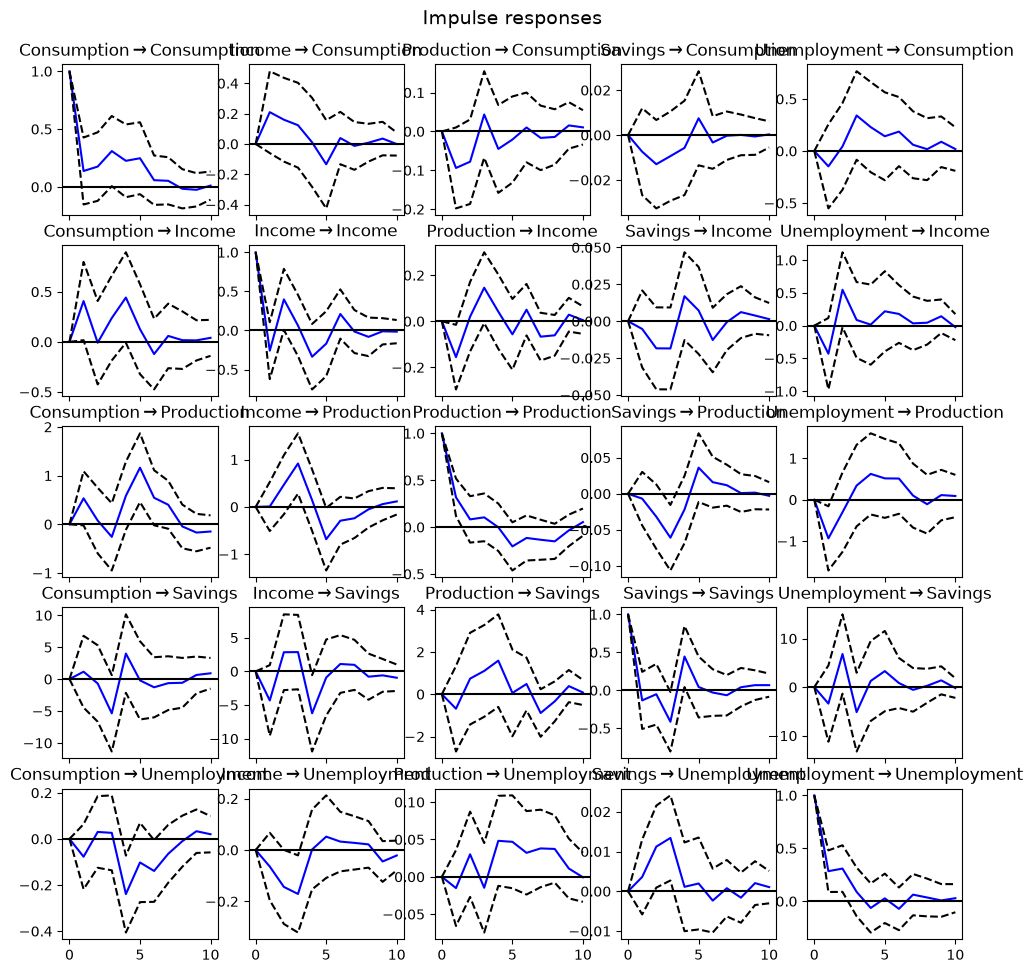

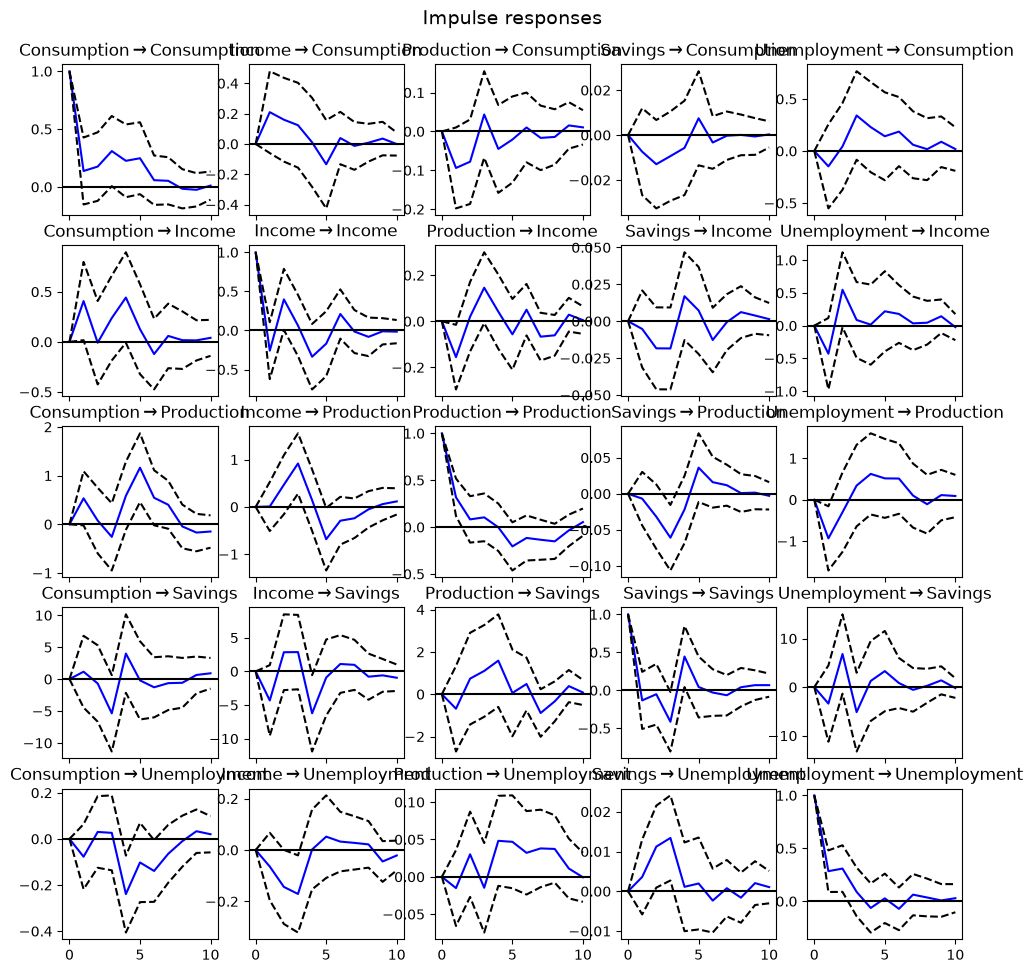

In [18]:
irf = fit_aic.irf(periods=10)
irf.plot(orth=False)

## [Slide 30] STL Decomposition for Bootstrapping

In [19]:
cement = (
    pd.read_csv("data/aus_production.csv", parse_dates=["ds"])
    [["ds", "Cement"]]
    .rename(columns={"Cement": "y"})
    .assign(unique_id="Cement")
)


In [20]:
from statsforecast.models import MSTL

sf = StatsForecast(
    models=[MSTL(season_length=4)], freq="QS"
)
sf = sf.fit(cement)
dcmp = sf.fitted_[0, 0].model_.assign(
    ds=cement["ds"].to_numpy()
)

def blocked_bootstrap(dcmp, block_size, num_sims):
    num_blocks = int(np.ceil(len(dcmp) / block_size))
    sim = {}
    for i in range(num_sims):
        blocks = []
        for _ in range(num_blocks):
            start = np.random.randint(
                0, len(dcmp) - block_size + 1)
            blocks.append(
                dcmp["remainder"].iloc[start:start+block_size]
            )
        sim[str(i)] = (
            dcmp["trend"] + dcmp["seasonal"]
            + pd.concat(blocks, ignore_index=True)[:len(dcmp)]
        )
    return pd.DataFrame(sim)

## [Slide 32] Bagged Forecasts

In [21]:
from statsforecast.models import AutoETS
from functools import reduce

sim_df = blocked_bootstrap(dcmp, block_size=8, num_sims=100)
sim_df = sim_df.assign(
    unique_id="Cement", ds=cement["ds"].to_numpy()
)

sf = StatsForecast(
    models=[AutoETS(season_length=4)], freq="QS"
)
forecasts = []
for col in sim_df.drop(columns=["ds","unique_id"]).columns:
    train = (sim_df[["unique_id","ds",col]]
             .rename(columns={col: "y"}))
    fc = sf.forecast(df=train, h=10)
    forecasts.append(fc)

## [Slide 34] Bagged Forecasts: Averaging

In [22]:
forecasts_df = reduce(
    lambda left, right: left.merge(right),
    forecasts
)

Average across all bootstrapped forecasts

In [23]:
fc_bagged = (
    forecasts_df
    .set_index(["unique_id", "ds"])
    .mean(axis="columns")
    .rename("BaggedETS")
    .reset_index()
)

Compare with direct ETS forecast

In [24]:
fc_ets = sf.forecast(df=cement, h=10)

## [Slide 37] Summary: Modules Used in Ch12 Multiple seasonality

In [25]:
from statsforecast.models import MSTL, AutoARIMA, AutoETS
from utilsforecast.feature_engineering import fourier, pipeline

Prophet

In [26]:
from prophet import Prophet
from statsforecast.models import AutoARIMAProphet

ImportError: cannot import name 'AutoARIMAProphet' from 'statsforecast.models' (/Data2/data/jc25/forecast/fpppy-labs/.venv/lib/python3.11/site-packages/statsforecast/models.py)

VAR

In [27]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf

Bootstrapping & bagging

In [28]:
import numpy as np
import pandas as pd
from functools import reduce